# Day 11: Random Forests & Feature Importance

Random Forest R2 Score: 0.7737


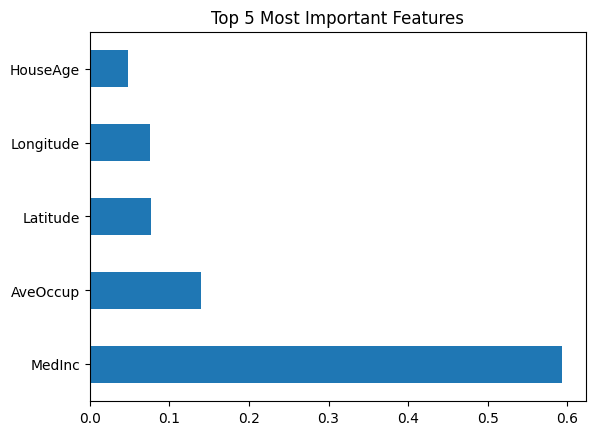

In [1]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt
import pandas as pd

# 1. Load Data
data = fetch_california_housing()
X_train, X_test, y_train, y_test = train_test_split(
    data.data, data.target, test_size=0.2, random_state=42
)

# 2. Initialize Model
rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    random_state=42
)

# 3. Train
rf_model.fit(X_train, y_train)

# 4. Predict
predictions = rf_model.predict(X_test)

# 5. Evaluate
print(f"Random Forest R2 Score: {r2_score(y_test, predictions):.4f}")

# 6. Feature Importance
importances = rf_model.feature_importances_
feature_names = data.feature_names

feat_importances = pd.Series(importances, index=feature_names)

# Plot
feat_importances.nlargest(5).plot(kind='barh')
plt.title("Top 5 Most Important Features")
plt.show()

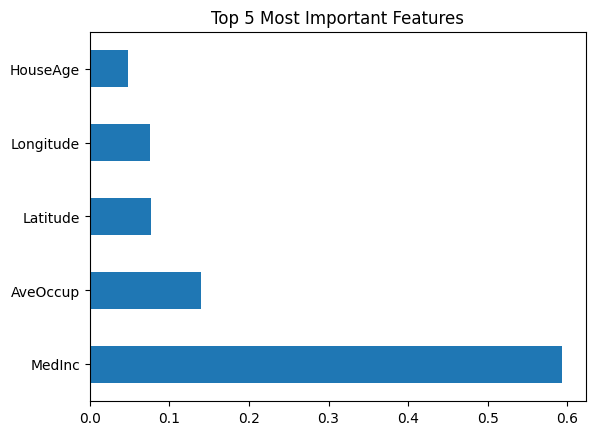

In [2]:
import matplotlib.pyplot as plt 
import pandas as pd 
# Get importance scores 
importances = rf_model.feature_importances_ 
feature_names = data.feature_names 
# Create a Series for easy plotting 
feat_importances = pd.Series(importances, index=feature_names) 
feat_importances.nlargest(5).plot(kind='barh') 
plt.title("Top 5 Most Important Features") 
plt.show() 


In [3]:
import time
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score

tree_counts = [10, 50, 200]

results = []

for n in tree_counts:
    start = time.time()

    model = RandomForestRegressor(n_estimators=n, random_state=42)
    model.fit(X_train, y_train)

    end = time.time()

    preds = model.predict(X_test)
    score = r2_score(y_test, preds)

    results.append((n, score, end - start))

# Print Results
for r in results:
    print(f"Trees: {r[0]} | R2 Score: {r[1]:.4f} | Time: {r[2]:.4f} sec")

Trees: 10 | R2 Score: 0.7831 | Time: 3.0524 sec
Trees: 50 | R2 Score: 0.8037 | Time: 16.9553 sec
Trees: 200 | R2 Score: 0.8062 | Time: 89.6260 sec


## Reflection
### As we increase the number of trees, does the accuracy keep going up forever, or do we hit a point of 'diminishing returns' where it just takes longer to train for very little gain?

As the number of trees increases, the model's accuracy improves initially because more trees reduce variance and make predictions more stable. 

However, after a certain point, the improvement becomes very small while training time continues to increase significantly. This shows diminishing returns, where adding more trees increases computational cost without meaningful performance gain.
